# Exercise: Handling Outliers

Please load `student_data.csv` and answer the following questions. Include your final code below. When you are done, click on `Run` > `Restart Kernel and Run All Cells...` and verify the output.
- Q: Capping outliers using IQR -'Exam_Score': How many outliers did you find in `Exam_Score`? What is the average `Exam_Score` before and after capping?
- A: 8 outliers were found, average before capping was 48.215410 and after capping is 35.458778
  
- Q: Remove Outliers Using Z-Score (3 Standard Deviations from the Mean) - 'Study_Hours': How many outliers did you find in 'Study_Hours'? What is the average `Study_Hours` before and after removing outliers?
- A: 3 out liers were found, average before dropping was 76.4 after dropping is 78.724316
- Q: Define the lower/upper bounds using IQR. Count and replace the outliers in `Age` with the median. How many outliers did you replace and what is the average of `Age` before and afterward?
- A: 3 outliers were found, the average before was 22.245408 and after is 21.953776

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
SD=pd.read_csv('student_data (1).csv')

In [5]:
SD

,Gender,Major,Exam_Score,Study_Hours,Age
0,Female,Science,1.23,1.09,19.26
1,Female,Arts,161.79,1.70,19.85
2,Male,Arts,10.26,5.60,22.10
3,Male,Commerce,18.59,90.74,21.42
4,Female,Science,19.63,82.44,23.83
...,...,...,...,...,...
93,Female,Arts,8.25,98.95,25.30
94,Female,Commerce,21.25,99.15,24.10
95,Male,Arts,3.28,99.17,23.30
96,Female,Arts,81.36,115.74,22.51


In [6]:
SD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gender       98 non-null     object 
 1   Major        98 non-null     object 
 2   Exam_Score   98 non-null     float64
 3   Study_Hours  98 non-null     float64
 4   Age          98 non-null     float64
dtypes: float64(3), object(2)
memory usage: 4.0+ KB


In [7]:
SD.describe().T

,count,mean,std,min,25%,50%,75%,max
Exam_Score,98.0,48.215510,54.073846,0.27,16.0675,30.480,56.0275,283.10
Study_Hours,98.0,76.400000,22.038976,1.09,63.2425,82.865,91.6825,132.66
Age,98.0,22.245408,2.581628,17.51,20.4600,22.105,23.6625,35.00


<Axes: xlabel='Exam_Score', ylabel='Count'>

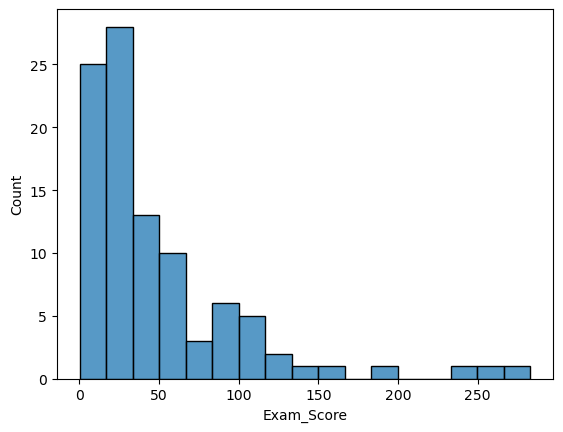

In [8]:
sns.histplot(data=SD, x='Exam_Score')

In [9]:
Q1=SD['Exam_Score'].quantile(0.25)

In [10]:
Q3=SD['Exam_Score'].quantile(0.75)

In [11]:
IQR=Q3-Q1

In [12]:
LB=Q1-1.5*IQR

In [13]:
UB=Q3+1.5*IQR

In [14]:
SD[(SD['Exam_Score']<LB)|(SD['Exam_Score']>UB)].count()

Gender         8
Major          8
Exam_Score     8
Study_Hours    8
Age            8
dtype: int64

In [15]:
SD1=SD[(SD['Exam_Score']>=LB)&(SD['Exam_Score']<=UB)]

In [16]:
SD1

,Gender,Major,Exam_Score,Study_Hours,Age
0,Female,Science,1.23,1.09,19.26
2,Male,Arts,10.26,5.60,22.10
3,Male,Commerce,18.59,90.74,21.42
4,Female,Science,19.63,82.44,23.83
5,Male,Commerce,30.99,84.24,21.36
...,...,...,...,...,...
93,Female,Arts,8.25,98.95,25.30
94,Female,Commerce,21.25,99.15,24.10
95,Male,Arts,3.28,99.17,23.30
96,Female,Arts,81.36,115.74,22.51


In [17]:
SD1.describe().T

,count,mean,std,min,25%,50%,75%,max
Exam_Score,90.0,35.458778,29.871031,0.27,14.3975,26.150,51.3700,106.86
Study_Hours,90.0,77.165778,21.095332,1.09,63.2500,83.540,91.6825,132.66
Age,90.0,22.302556,2.644079,17.51,20.4600,22.105,23.7100,35.00


<Axes: xlabel='Exam_Score', ylabel='Count'>

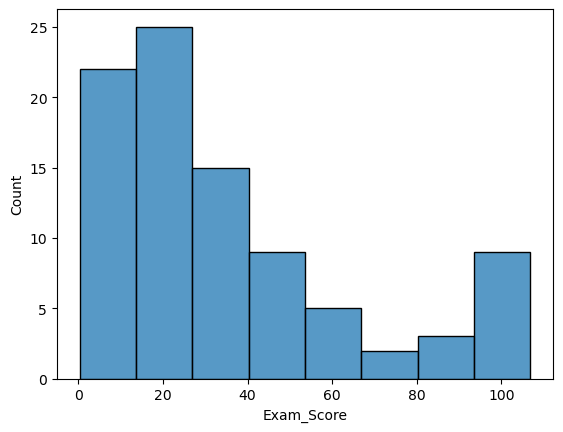

In [18]:
sns.histplot(data=SD1, x='Exam_Score')

<Axes: xlabel='Study_Hours', ylabel='Count'>

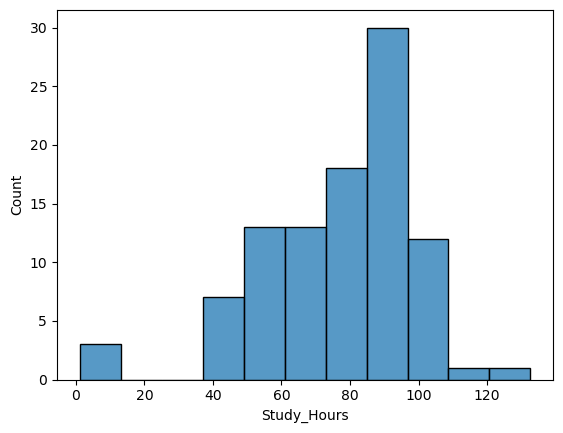

In [19]:
sns.histplot(data=SD, x='Study_Hours')

In [20]:
upper_bound=SD['Study_Hours'].mean()+3*SD['Study_Hours'].std()

In [21]:
lower_bound=SD['Study_Hours'].mean()-3*SD['Study_Hours'].std()

In [22]:
SD[(SD['Study_Hours']<lower_bound)|(SD['Study_Hours']>upper_bound)].count()

Gender         3
Major          3
Exam_Score     3
Study_Hours    3
Age            3
dtype: int64

In [23]:
SD2=SD[(SD['Study_Hours']>=lower_bound)&(SD['Study_Hours']<=upper_bound)] 

In [24]:
SD2

,Gender,Major,Exam_Score,Study_Hours,Age
3,Male,Commerce,18.59,90.74,21.42
4,Female,Science,19.63,82.44,23.83
5,Male,Commerce,30.99,84.24,21.36
6,Female,Science,88.67,88.15,23.52
7,Male,Arts,99.27,65.46,22.81
...,...,...,...,...,...
93,Female,Arts,8.25,98.95,25.30
94,Female,Commerce,21.25,99.15,24.10
95,Male,Arts,3.28,99.17,23.30
96,Female,Arts,81.36,115.74,22.51


In [25]:
SD2.describe().T

,count,mean,std,min,25%,50%,75%,max
Exam_Score,95.0,47.914105,53.302637,0.27,17.04,30.99,55.785,283.10
Study_Hours,95.0,78.724316,17.964782,44.26,64.41,83.25,92.330,132.66
Age,95.0,22.303579,2.591912,17.51,20.51,22.14,23.700,35.00


<Axes: xlabel='Study_Hours', ylabel='Count'>

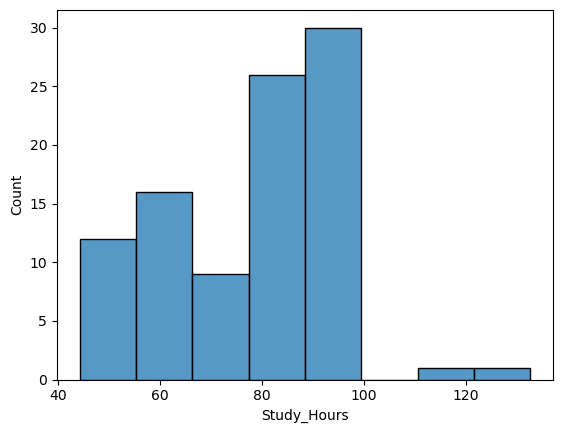

In [26]:
sns.histplot(data=SD2, x='Study_Hours')

In [27]:
import numpy as np

<Axes: xlabel='Age', ylabel='Count'>

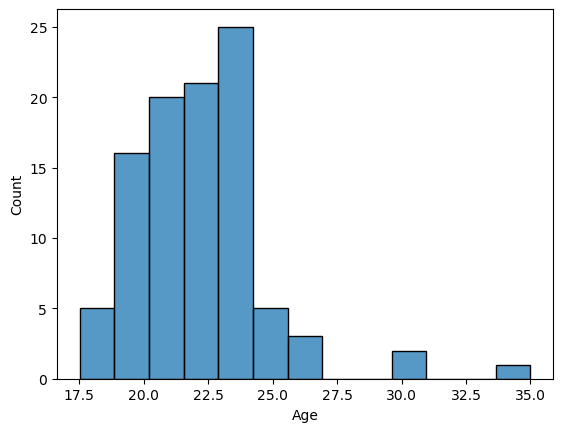

In [28]:
sns.histplot(data=SD, x='Age')

In [29]:
#define q1,q3, iqr
q1=SD['Age'].quantile(0.25)
q3=SD['Age'].quantile(0.75)
iqr=q3-q1

In [30]:
lower_bound=q1-1.5*iqr

In [31]:
upper_bound=q3+1.5*iqr

In [32]:
Median=SD['Age'].median()

In [33]:
SD[(SD['Age'] < lower_bound) | (SD['Age'] > upper_bound)].count()

Gender         3
Major          3
Exam_Score     3
Study_Hours    3
Age            3
dtype: int64

In [34]:
SD['Age'] = np.where((SD['Age'] < lower_bound) | (SD['Age'] > upper_bound), Median,SD['Age'])

In [35]:
SD.describe().T

,count,mean,std,min,25%,50%,75%,max
Exam_Score,98.0,48.215510,54.073846,0.27,16.0675,30.4800,56.0275,283.10
Study_Hours,98.0,76.400000,22.038976,1.09,63.2425,82.8650,91.6825,132.66
Age,98.0,21.952704,1.913603,17.51,20.4600,22.1025,23.5275,26.20


<Axes: xlabel='Age', ylabel='Count'>

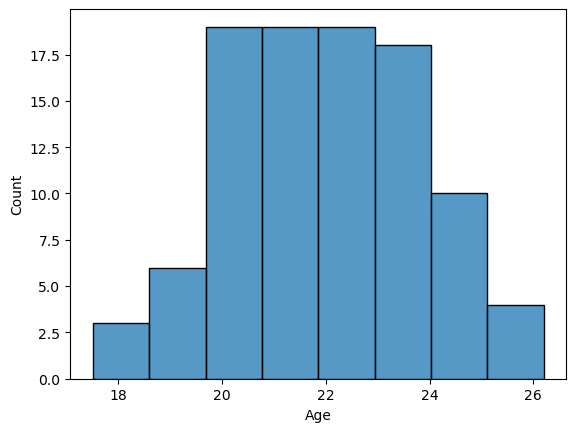

In [36]:
sns.histplot(data=SD, x='Age')